In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

from config import RANDOM_STATE, N_CLIENTS, SECTOR_TIME_SERIES_MONTHS
from src.data_generation import SyntheticCreditDataGenerator
from src.pd_model import PDModel
from src.lgd_model import LGDModel
from src.ead_model import EADModel
from src.staging import assign_stage
from src.ecl_engine import calculate_ecl
from src.sector_risk import (
    sector_exposure_summary,
    build_sector_time_series,
    sector_correlation_matrix,
    find_natural_hedges,
)
from src.portfolio_policy import (
    build_sector_policy_flags,
    indicative_sector_pricing,
    build_sector_attractiveness_index,
)

plt.rcParams["figure.figsize"] = (9, 5)

In [4]:
generator = SyntheticCreditDataGenerator(
    n_clients=N_CLIENTS,
    random_state=RANDOM_STATE,
)

df = generator.generate()
df.head()

,client_id,age,income,ltv,dti,bureau_score,utilization,months_on_book,dpd,has_collateral,...,balance,undrawn,unemployment,selic_proxy,gdp_growth,true_pd_12m,default_12m,true_lgd,ccf,true_ead
0,1,25,2772.956975,0.536706,0.721648,598.038701,0.328682,85,30,0,...,11338.605062,0.000000,0.086019,0.131901,0.028589,0.011281,0,0.782532,0.623410,11338.605062
1,2,62,2157.783330,0.533867,0.480623,745.708809,0.675676,74,15,1,...,6260.675977,1834.449666,0.105159,0.110564,0.020706,0.005398,0,0.773227,0.868857,7854.550802
2,3,56,10341.566652,0.293383,0.397382,579.625391,0.463096,65,30,1,...,9333.697320,0.000000,0.089628,0.117092,-0.001617,0.004040,0,0.690450,0.689786,9333.697320
3,4,44,18626.607451,0.566854,0.406334,612.443682,0.663039,93,60,1,...,9546.348875,432.484648,0.089813,0.124779,0.017039,0.016973,0,0.884341,0.746684,9869.278273
4,5,44,3783.247264,0.207920,0.595931,781.652972,0.240833,106,0,1,...,1602.716941,0.000000,0.071780,0.104850,0.030240,0.001522,0,0.607415,0.585830,1602.716941


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   client_id       8000 non-null   int32  
 1   age             8000 non-null   int64  
 2   income          8000 non-null   float64
 3   ltv             8000 non-null   float64
 4   dti             8000 non-null   float64
 5   bureau_score    8000 non-null   float64
 6   utilization     8000 non-null   float64
 7   months_on_book  8000 non-null   int64  
 8   dpd             8000 non-null   int32  
 9   has_collateral  8000 non-null   int32  
 10  segment         8000 non-null   object 
 11  product         8000 non-null   object 
 12  sector          8000 non-null   object 
 13  balance         8000 non-null   float64
 14  undrawn         8000 non-null   float64
 15  unemployment    8000 non-null   float64
 16  selic_proxy     8000 non-null   float64
 17  gdp_growth      8000 non-null   f

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,8000.0,NaN,NaN,NaN,4000.5,2309.54541,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,NaN,NaN,NaN,47.2445,15.565427,21.0,34.0,47.0,61.0,74.0
income,8000.0,NaN,NaN,NaN,5711.054091,3474.696242,439.653527,3387.103477,4853.829931,7074.049805,48203.300287
ltv,8000.0,NaN,NaN,NaN,0.584777,0.180022,0.05,0.461856,0.58265,0.706509,1.156044
dti,8000.0,NaN,NaN,NaN,0.32534,0.147954,0.01,0.223567,0.325016,0.42357,0.872376
bureau_score,8000.0,NaN,NaN,NaN,679.568001,84.859215,318.15421,621.974153,679.513826,737.4126,900.0
utilization,8000.0,NaN,NaN,NaN,0.424926,0.193188,0.006417,0.276437,0.412947,0.565085,0.982912
months_on_book,8000.0,NaN,NaN,NaN,60.88075,34.452404,1.0,31.0,61.0,91.0,120.0
dpd,8000.0,NaN,NaN,NaN,13.1575,26.278632,0.0,0.0,0.0,15.0,120.0
has_collateral,8000.0,NaN,NaN,NaN,0.648625,0.47743,0.0,0.0,1.0,1.0,1.0


In [7]:
pd_model = PDModel(random_state=RANDOM_STATE)
pd_model.fit(df)
df["pd_12m_model"] = pd_model.predict_pd_12m(df)

lgd_model = LGDModel(random_state=RANDOM_STATE)
lgd_model.fit(df)
df["lgd_model"] = lgd_model.predict_lgd(df)

ead_model = EADModel(random_state=RANDOM_STATE)
ead_model.fit(df)
df["ead_model"] = ead_model.predict_ead(df)

df["stage"] = assign_stage(df, df["pd_12m_model"].values)

ecl_df = calculate_ecl(
    pd_12m=df["pd_12m_model"].values,
    lgd=df["lgd_model"].values,
    ead=df["ead_model"].values,
    stage=df["stage"],
)

result = pd.concat([df, ecl_df[["ecl_12m", "ecl_lifetime", "final_ecl"]]], axis=1)
result.head()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,client_id,age,income,ltv,dti,bureau_score,utilization,months_on_book,dpd,has_collateral,...,true_lgd,ccf,true_ead,pd_12m_model,lgd_model,ead_model,stage,ecl_12m,ecl_lifetime,final_ecl
0,1,25,2772.956975,0.536706,0.721648,598.038701,0.328682,85,30,0,...,0.782532,0.623410,11338.605062,0.006278,0.757427,11427.446719,2,48.520484,96.509385,96.509385
1,2,62,2157.783330,0.533867,0.480623,745.708809,0.675676,74,15,1,...,0.773227,0.868857,7854.550802,0.004244,0.675119,7672.758136,1,19.627215,39.076230,19.627215
2,3,56,10341.566652,0.293383,0.397382,579.625391,0.463096,65,30,1,...,0.690450,0.689786,9333.697320,0.004050,0.608000,9413.161699,2,20.693712,41.203244,41.203244
3,4,44,18626.607451,0.566854,0.406334,612.443682,0.663039,93,60,1,...,0.884341,0.746684,9869.278273,0.009438,0.762109,9737.246499,2,62.535568,124.203772,124.203772
4,5,44,3783.247264,0.207920,0.595931,781.652972,0.240833,106,0,1,...,0.607415,0.585830,1602.716941,0.001585,0.500335,1556.256981,1,1.102240,2.197174,1.102240


In [8]:
result[["pd_12m_model", "lgd_model", "ead_model", "final_ecl"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pd_12m_model,8000.0,0.006048,0.006567,0.000072,0.002306,0.004164,0.007366,0.099776
lgd_model,8000.0,0.689705,0.092831,0.468778,0.613638,0.681011,0.756972,0.921735
ead_model,8000.0,14081.773909,15417.655088,1064.847406,5261.297869,9411.416770,16917.584296,140884.644969
final_ecl,8000.0,88.697440,217.944626,0.169373,11.280395,29.569007,77.773938,5172.564545


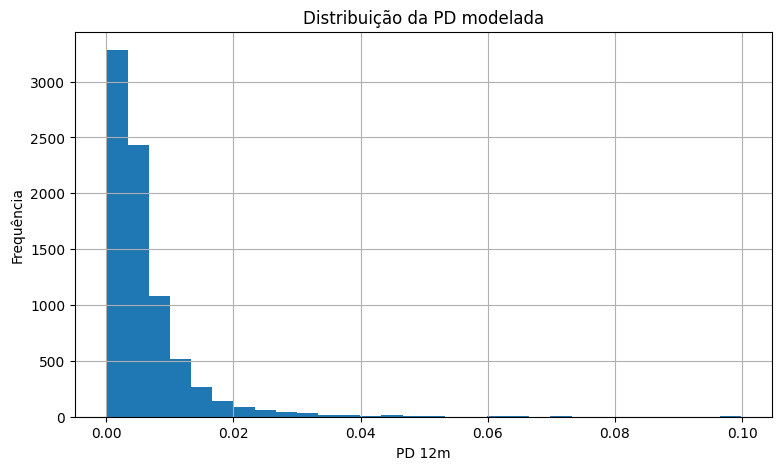

In [9]:
result["pd_12m_model"].hist(bins=30)
plt.title("Distribuição da PD modelada")
plt.xlabel("PD 12m")
plt.ylabel("Frequência")
plt.show()

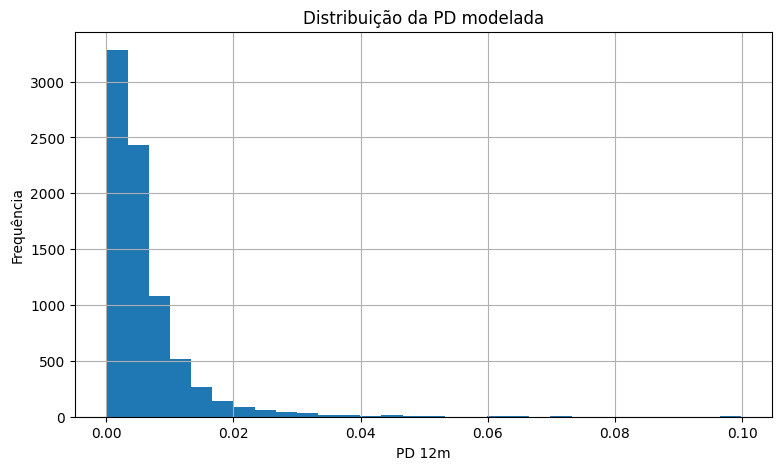

In [10]:
result["pd_12m_model"].hist(bins=30)
plt.title("Distribuição da PD modelada")
plt.xlabel("PD 12m")
plt.ylabel("Frequência")
plt.show()

In [11]:
result["stage"].value_counts().sort_index()

stage
1    5187
2    2351
3     462
Name: count, dtype: int64

In [12]:
sector_summary = sector_exposure_summary(result)
sector_summary

,sector,n_clients,total_ead,total_ecl,avg_pd,avg_lgd,avg_stage,ead_share,risk_cost
0,retail,1972,2.761598e+07,164222.259683,0.006149,0.689597,1.372211,0.245139,0.005947
1,industry,1271,1.774245e+07,100322.570898,0.005681,0.689702,1.341463,0.157495,0.005654
2,agribusiness,1139,1.654474e+07,93777.911877,0.005675,0.687368,1.413521,0.146863,0.005668
3,utilities,976,1.348783e+07,76312.512296,0.005560,0.689840,1.421107,0.119728,0.005658
4,transport,943,1.336189e+07,133542.377979,0.008519,0.690988,1.541888,0.118610,0.009994
5,healthcare,890,1.275320e+07,116205.879174,0.008016,0.691645,1.576404,0.113207,0.009112
6,technology,809,1.114810e+07,25196.008055,0.002446,0.689471,1.248455,0.098959,0.002260


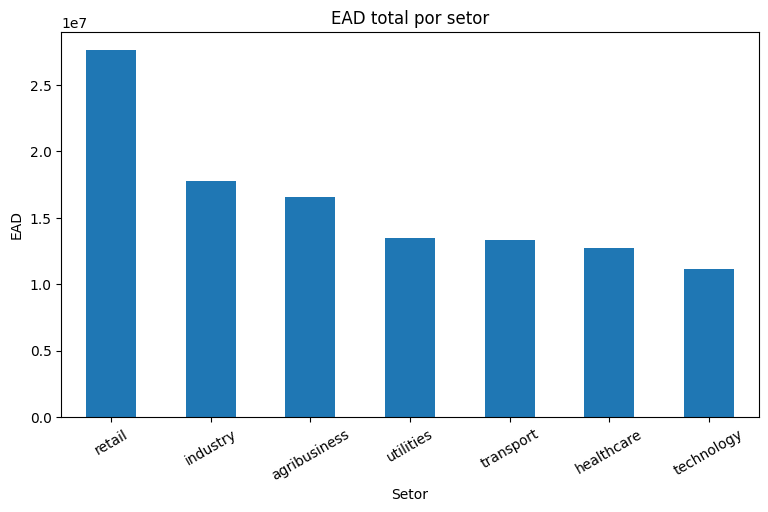

In [13]:
sector_summary.sort_values("total_ead", ascending=False).plot(
    kind="bar",
    x="sector",
    y="total_ead",
    legend=False,
    rot=30,
)
plt.title("EAD total por setor")
plt.xlabel("Setor")
plt.ylabel("EAD")
plt.show()

In [14]:
sector_ts = build_sector_time_series(
    n_months=SECTOR_TIME_SERIES_MONTHS,
    random_state=RANDOM_STATE,
)

corr_matrix = sector_correlation_matrix(sector_ts)
corr_matrix

sector,agribusiness,healthcare,industry,retail,technology,transport,utilities
sector,,,,,,,
agribusiness,1.000000,0.438117,0.637445,0.418167,0.010500,0.620459,0.130476
healthcare,0.438117,1.000000,0.480507,0.246740,-0.199983,0.242615,0.230284
industry,0.637445,0.480507,1.000000,0.718976,0.318762,0.749415,-0.167215
retail,0.418167,0.246740,0.718976,1.000000,0.525548,0.605773,-0.430554
technology,0.010500,-0.199983,0.318762,0.525548,1.000000,0.238354,-0.678482
transport,0.620459,0.242615,0.749415,0.605773,0.238354,1.000000,-0.139235
utilities,0.130476,0.230284,-0.167215,-0.430554,-0.678482,-0.139235,1.000000


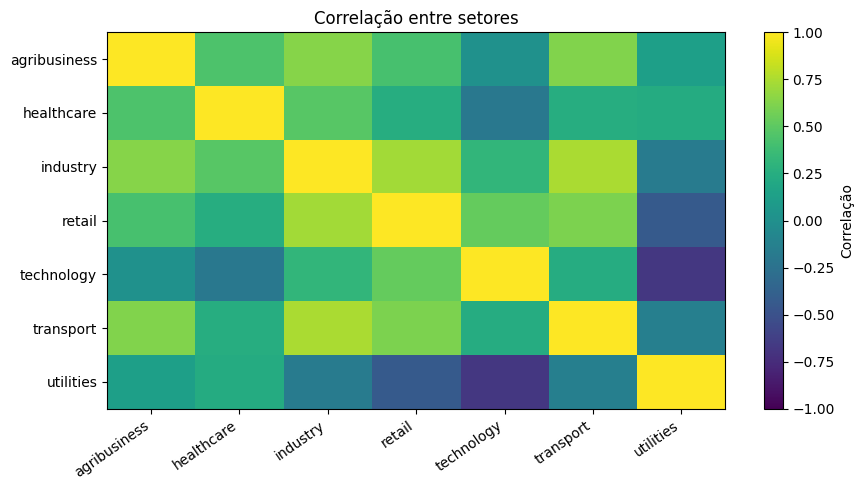

In [15]:
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=35, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlação entre setores")
plt.tight_layout()
plt.show()

In [16]:
hedges = find_natural_hedges(corr_matrix, threshold=0.0)
hedges.head(10)

,sector_a,sector_b,correlation
0,technology,utilities,-0.678482
1,retail,utilities,-0.430554
2,healthcare,technology,-0.199983
3,industry,utilities,-0.167215
4,transport,utilities,-0.139235


In [17]:
sector_policy = build_sector_policy_flags(sector_summary)
sector_pricing = indicative_sector_pricing(sector_policy)

sector_attractiveness = build_sector_attractiveness_index(
    exposure_df=sector_pricing,
    corr_matrix=corr_matrix,
)

sector_attractiveness[
    [
        "sector",
        "sector_attractiveness_index",
        "sector_attractiveness_rank",
        "strategic_bucket",
        "avg_pd",
        "avg_lgd",
        "ead_share",
        "marginal_corr_to_book",
        "indicative_spread",
    ]
]

,sector,sector_attractiveness_index,sector_attractiveness_rank,strategic_bucket,avg_pd,avg_lgd,ead_share,marginal_corr_to_book,indicative_spread
0,technology,-0.153039,1,expand_selectively,0.002446,0.689471,0.098959,0.284937,0.198769
1,utilities,-0.173024,2,expand_selectively,0.005560,0.689840,0.119728,-0.155764,0.202165
2,agribusiness,-0.199699,3,neutral_monitoring,0.005675,0.687368,0.146863,0.527806,0.204430
3,retail,-0.210905,4,neutral_monitoring,0.006149,0.689597,0.245139,0.568571,0.214893
4,industry,-0.291240,5,neutral_monitoring,0.005681,0.689702,0.157495,0.678210,0.205962
5,healthcare,-0.415770,6,restrict_or_reprice,0.008016,0.691645,0.113207,0.388455,0.202856
6,transport,-0.456173,7,restrict_or_reprice,0.008519,0.690988,0.118610,0.658549,0.203466


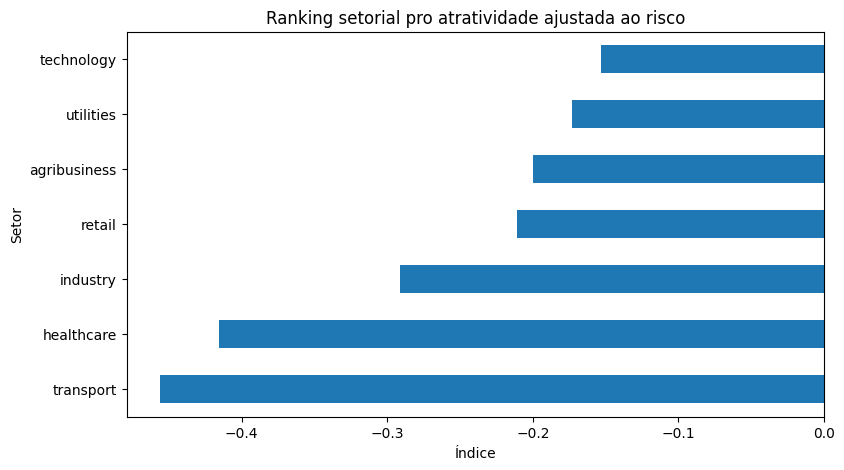

In [19]:
sector_attractiveness.sort_values(
    "sector_attractiveness_index",
    ascending=True
).plot(
    kind="barh",
    x="sector",
    y="sector_attractiveness_index",
    legend=False,
)
plt.title("Ranking setorial pro atratividade ajustada ao risco")
plt.xlabel("Índice")
plt.ylabel("Setor")
plt.show()

## Próximos passos

Este notebook ainda utiliza dados sintéticos para demonstração da arquitetura analítica.

Evoluções planejadas:
- integração com dados reais do IPEA;
- integração com dados do Banco Central;
- integração com dados da Receita Federal;
- inclusão de séries históricas reais por setor;
- backtesting temporal;
- survival models para lifetime PD;
- análise de correlação em janelas móveis e em estresse.

# TODO:
# 1. Substituir o gerador sintético por pipelines reais de ingestão
# 2. Criar loaders dedicados para IPEA / Bacen / Receita Federal
# 3. Padronizar chaves setoriais e granularidade temporal
# 4. Reestimar correlações com séries observadas
# 5. Testar estabilidade do índice de atratividade por janela temporal